### Imports

In [1]:
import math
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import colormaps

import gymnasium as gym
from MyoElbowPose2D6M import MyoElbowPose2D6MFixed

### Constants

In [2]:
# --- Simulation parameters ---
dt, tau_n, tau_m = 0.01, 0.02, 0.05

# --- Neural network parameters ---
n_s, n_m1, n_muscles, n_inputs = 200, 200, 6, 10

# --- Feedback gains ---
G_p, G_d, G_f = 1.0, 1.0, 1.0

# --- Reflex parameters ---
G_aff = torch.tensor([1.0, 0.1, 0.01, 0.0001])
G_s_low, G_s_high = 0.8, 1.9
reflex_delay = int(0.02 / dt)

# --- Activation and feedback delay ---
activation_delay_steps = int(0.03 / dt)
feedback_delay_steps = int(0.04 / dt) 

# --- Moment arm matrix ---
M_m = torch.tensor([[0.1, 0.02], [0.08, 0.01], [0.06, 0.01], [-0.06, -0.02], [-0.08, -0.01], [-0.1, -0.02]])

# --- Penalty coefficients ---
alpha, beta, gamma = 0.0001, 0.01, 0.5

# --- External loads ---
background_load_low, background_load_high, perturbation_load = 0.1, 0.55, 0.25

# --- Time parameters and steps ---
Tb, Tsb, Tp, Tsp, T = 0.20, 1.00, 1.50, 2.50, 3.00
Tb_step, Tsb_step, Tp_step, Tsp_step, T_step = int(Tb / dt), int(Tsb / dt), int(Tp / dt), int(Tsp / dt), int(T / dt)

# --- Perturbation directions ---
perturbation_directions = [np.array([1.0, 0.0]), np.array([-1.0, 0.0]), np.array([0.0, 1.0]), np.array([0.0, -1.0]),
                           np.array([0.707, 0.707]), np.array([-0.707, 0.707]), np.array([-0.707, -0.707]), np.array([0.707, -0.707])]

### Neural Limb Controller

In [3]:
class NeuralLimbController(nn.Module):
    """Neural controller for a two-segment limb model."""

    def __init__(self, n_inputs, n_outputs=n_muscles):
        super().__init__()
        
        # Sensory layer
        self.w_sr = self._init_weights(n_s, n_s, n_inputs)
        self.w_si = self._init_weights(n_s, n_inputs, n_inputs)
        self.b_s = nn.Parameter(torch.full((n_s,), 0.1))

        # M1 layer
        self.w_mr = self._init_weights(n_m1, n_m1, n_s)
        self.w_mi = self._init_weights(n_m1, n_s, n_s)
        self.b_m = nn.Parameter(torch.full((n_m1,), 0.1))

        # Muscle activation layer
        self.w_act = self._init_weights(n_muscles, n_m1, n_m1)

        # Internal state variables
        self.y_s = torch.zeros(n_s)
        self.y_m = torch.zeros(n_m1)
        self.y_act = torch.zeros(n_muscles)

    @staticmethod
    def _init_weights(out_dim, in_dim, scale_dim):
        """Helper function to initialize weights."""
        return nn.Parameter(torch.empty(out_dim, in_dim).uniform_(-1 / np.sqrt(scale_dim), 1 / np.sqrt(scale_dim)))
    
    def reset_states(self):
        """Reset the internal states of the controller."""
        self.y_s.zero_()
        self.y_m.zero_()
        self.y_act.zero_()

    def reset_weights(self):
        """Reinitialize the weights of the controller."""
        for param in [self.w_sr, self.w_si, self.w_mr, self.w_mi, self.w_act]:
            param.data.uniform_(-1 / np.sqrt(param.size(1)), 1 / np.sqrt(param.size(1)))

    def neural_activation_step(self, y_t, u_t):
        """Discretized neural activation dynamics."""
        return (1 - (dt / tau_n)) * y_t + (dt / tau_n) * torch.tanh(u_t)
    
    def muscle_activation_step(self, y_act_t, u_act_t):
        """Discretized muscle activation dynamics."""
        return (1 - (dt / tau_m)) * y_act_t + (dt / tau_m) * torch.relu(u_act_t)

    def forward_step(self, u_fb_t, x_aff_t, y_s_delayed_t, G_s):
        """Perform a single forward step of the neural controller."""
        self.y_s = self.neural_activation_step(self.y_s, self.w_sr @ y_s_delayed_t + self.w_si @ u_fb_t + self.b_s)
        self.y_m = self.neural_activation_step(self.y_m, self.w_mr @ self.y_m + self.w_mi @ self.y_s + self.b_m)
        self.y_act = self.muscle_activation_step(self.y_act, self.w_act @ self.y_m + G_s * x_aff_t)
        return self.y_act

### Hill-type muscle model equations

In [4]:
class MuscleConstants:
    """Class to store physiologically based constants for muscle dynamics."""
    F_MAX = 1.0               # Maximum isometric force (used for normalization)
    L_OPT = 1.0               # Optimal fiber length (used for normalization)
    V_MAX = 10.0              # Maximum shortening velocity (V_max / L_opt)

    # Coefficients for Shortening
    A_HILL = 0.25             # Normalized coefficient 'a/F_max'
    B_HILL = A_HILL * V_MAX   # Normalized coefficient 'b/L_opt'

    # Coefficients for Lengthening
    K_ECC = 0.15              # Shape factor for the eccentric regime
    F_MAX_ECC = 1.4           # Max force during lengthening (1.4 * F_max)


class ForceLength:
    """Class to compute the force-length relationship for muscles."""
    @staticmethod
    def compute(L_m, L_opt=MuscleConstants.L_OPT, width_factor=0.4):
        """
        Args:
            L_m (torch.Tensor): Normalized muscle length.
            L_opt (float): Optimal fiber length (default: 1.0).
            width_factor (float): Controls the width of the bell curve (default: 0.4).

        Returns:
            torch.Tensor: Force-Length scaling factor (FL).
        """
        exp = -((L_m - L_opt) / width_factor).pow(2)
        return torch.exp(exp)


class ForceVelocity:
    """Class to compute the force-velocity relationship for muscles."""
    @staticmethod
    def compute(dLm_dt, V_max=MuscleConstants.V_MAX, A_hill=MuscleConstants.A_HILL, 
                B_hill=MuscleConstants.B_HILL, F_max_ecc=MuscleConstants.F_MAX_ECC, 
                K_ecc=MuscleConstants.K_ECC):
        """
        Args:
            dLm_dt (torch.Tensor): Normalized muscle velocity (positive for lengthening, negative for shortening).
            V_max (float): Maximum shortening velocity.
            A_hill (float): Hill's coefficient 'a/F_max'.
            B_hill (float): Hill's coefficient 'b/L_opt'.
            F_max_ecc (float): Max force during lengthening.
            K_ecc (float): Shape factor for the eccentric regime.

        Returns:
            torch.Tensor: Force-Velocity scaling factor (FV).
        """
        # Shortening (dLm_dt <= 0): Hill's hyperbolic equation
        FV_shortening = (B_hill - dLm_dt) / (B_hill + A_hill * dLm_dt)
        # Lengthening (dLm_dt > 0): Exponential plateau
        FV_lengthening = (F_max_ecc - 1.0) * (1.0 - torch.exp(-K_ecc * dLm_dt)) + 1.0
        # Combine shortening and lengthening regimes
        return torch.where(dLm_dt <= 0.0, FV_shortening, FV_lengthening)

### Cost functions

In [5]:
def compute_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated):
    """Compute the neural, force, and kinematic costs."""
    # Neural cost (Instantaneous mean of squared activity)
    neural_cost = controller.y_s.pow(2).mean() + controller.y_m.pow(2).mean()

    # Force output cost (Instantaneous mean of squared force)
    force_cost = F_m.pow(2).mean()

    # Kinematic cost (Final Time-Averaged Costs)
    J_b_1_duration = Tb
    J_b_2_duration = Tp - Tsb
    J_p_duration = T - Tsp

    # Time-Averaged Cost = Integral / Duration
    J_b_1_final = J_b_1_accumulated / J_b_1_duration
    J_b_2_final = J_b_2_accumulated / J_b_2_duration
    J_p_final = J_p_accumulated / J_p_duration
    
    # J_b is the sum of its two components
    J_b_final = J_b_1_final + J_b_2_final
    
    # Total Kinematic Cost
    kinematic_cost = J_b_final + J_p_final

    return neural_cost, force_cost, kinematic_cost, J_b_final, J_p_final

def compute_weighted_costs(neural_cost, force_cost, kinematic_cost, J_b_final, J_p_final, alpha, beta, gamma):
    """Compute weighted components of the cost."""
    return {
        "neural": alpha * neural_cost,
        "force": beta * force_cost,
        "J_b": gamma * J_b_final,
        "J_p": gamma * J_p_final,
        "kinematic": gamma * kinematic_cost,
        "total": alpha * neural_cost + beta * force_cost + gamma * kinematic_cost,
    }

def compute_and_accumulate_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated, total_costs):
    """Compute costs, apply weights, and accumulate them into total_costs."""
    # Compute costs
    neural_cost, force_cost, kinematic_cost, J_b_final, J_p_final = compute_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated)
    weighted_costs = compute_weighted_costs(neural_cost, force_cost, kinematic_cost, J_b_final, J_p_final, alpha, beta, gamma)

    # Add L2 regularization to the total cost
    total_cost = weighted_costs["total"]
    l2_reg = 0.01 * sum(p.pow(2).sum() for p in controller.parameters())
    total_cost += l2_reg

    # Accumulate costs
    for key in total_costs:
            if key == "J_b":
                total_costs[key] += weighted_costs[key].item() 
            elif key == "J_p":
                total_costs[key] += weighted_costs[key].item()
            elif key == "neural" or key == "force":
                total_costs[key] += weighted_costs[key].item()
            elif key == "kinematic":
                total_costs[key] += weighted_costs[key].item()
            elif key == "total":
                total_costs[key] += weighted_costs[key].item()

    return total_cost

### Training Loop

In [6]:
# Initialize environment and controller
env = MyoElbowPose2D6MFixed()
controller = NeuralLimbController(n_inputs=n_inputs, n_outputs=n_muscles)

# Set up optimizer and scheduler
optimizer = torch.optim.Adam(controller.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

# Initialize results storage
target_results = {
    i: {
        "pose_errors": [],
        "rewards": [],
        "costs": {"neural": [], "force": [], "kinematic": [], "J_b": [], "J_p": [], "total": []},
        "spinal_contrib": [], "cortical_contrib": [], "muscle_activations": [],
        "reflex_gain": [], "cortical_activity": [], "sensory_activity": [], "motor_activity": []
    }
    for i in range(len(perturbation_directions))
}

In [8]:
# Training loop
num_epochs = 10
epoch_metadata = []
epoch_qpos_over_time = []
epoch_external_loads = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")

    # Reset controller weights and states
    controller.reset_weights()
    controller.reset_states()

    # Randomly select background load condition
    background_load = random.choice([background_load_low, background_load_high])
    load_condition = "High" if background_load == background_load_high else "Low"
    G_s = G_s_high if background_load == background_load_high else G_s_low

    # Select a random perturbation direction
    perturbation_idx = random.randint(0, len(perturbation_directions) - 1)
    perturbation_dir = perturbation_directions[perturbation_idx]
    direction_name = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"][perturbation_idx]

    # Store metadata for this epoch
    epoch_metadata.append({"load": load_condition, "direction": direction_name})

    # Reset the environment
    obs, _ = env.reset(target_qpos=(0.0, 0.0))

    # Initialize accumulators and buffers
    J_b_1_accumulated = torch.tensor(0.0, requires_grad=True)
    J_b_2_accumulated = torch.tensor(0.0, requires_grad=True)
    J_p_accumulated = torch.tensor(0.0, requires_grad=True)
    total_costs = {"neural": 0.0, "force": 0.0, "J_b": 0.0, "J_p": 0.0, "kinematic": 0.0, "total": 0.0}
    activation_buffer = [torch.zeros(n_muscles) for _ in range(activation_delay_steps)]
    delayed_activations = activation_buffer[0]

    # Storage for this epoch
    pose_errors, rewards = [], []
    qpos_over_time = []
    external_load_over_time = []
    epoch_costs = {key: [] for key in total_costs.keys()}

    L_m = torch.tensor([1.05, 1.02, 1.00, 0.98, 0.97, 0.99], requires_grad=True)
    L_m_initial = L_m.clone().detach()
    delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = torch.zeros(n_muscles), torch.zeros(n_muscles), torch.zeros(n_muscles), torch.zeros(n_muscles)

    for step in range(T_step):
        # Detach internal states
        for state in [controller.y_s, controller.y_m, controller.y_act]:
            state.detach_()

        # Set external torque based on the current phase
        if step < Tb_step:
            env.set_external_torque(np.array([0.0, 0.0]))
        elif Tb_step <= step < Tp_step:
            env.set_external_torque(background_load * perturbation_dir)
        elif Tp_step <= step < Tsp_step:
            env.set_external_torque((background_load + perturbation_load) * perturbation_dir)
        else:
            env.set_external_torque(background_load * perturbation_dir)

        # Track external load
        external_load_over_time.append(env.external_torque.copy())

        # Compute pose error
        target_qpos = (0.0, 0.0)
        pose_error = np.sqrt((target_qpos[0] - obs[0])**2 + (target_qpos[1] - obs[2])**2)

        # Compute velocity feedback
        velocity_feedback = torch.tensor([obs[1], obs[3]], dtype=torch.float32)  # Joint velocities

        # Combine feedback signals
        proprioceptive_feedback = torch.cat((torch.tensor([pose_error], dtype=torch.float32), velocity_feedback, torch.tensor(obs[:10], dtype=torch.float32)))

        # Compute kinematic loss term
        kinematic_loss_term = (torch.tensor(obs[:2]) - torch.tensor(target_qpos)).pow(2).mean() + 0.5 * torch.tensor(obs[1:3]).pow(2).mean()
        kinematic_loss_integral = kinematic_loss_term * dt

        # Accumulate kinematic costs
        if step < Tb_step:
            with torch.no_grad():
                J_b_1_accumulated += kinematic_loss_integral.detach()
        if Tsb_step <= step < Tp_step:
            with torch.no_grad():
                J_b_2_accumulated += kinematic_loss_integral.detach()
        if Tsp_step <= step < T_step:
            with torch.no_grad():
                J_p_accumulated += kinematic_loss_integral.detach()

        # Compute muscle length changes
        dLm_dt = (-M_m @ torch.tensor(obs[1:3], dtype=torch.float32).unsqueeze(1)).squeeze()
        new_L_m = L_m + dLm_dt * dt
        new_L_m, dLm_dt = new_L_m.detach(), dLm_dt.detach()

        # Update muscle kinematics
        new_delta_L_m = new_L_m - L_m_initial
        new_velocity_L_m = dLm_dt
        new_acceleration_L_m = (new_velocity_L_m - velocity_L_m) / dt
        new_jerk_L_m = (new_acceleration_L_m - acceleration_L_m) / dt

        L_m, delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m = new_L_m, new_delta_L_m, new_velocity_L_m, new_acceleration_L_m, new_jerk_L_m
        x_m = torch.stack([delta_L_m, velocity_L_m, acceleration_L_m, jerk_L_m], dim=1)
        x_aff_t = G_aff @ x_m.T

        # Compute muscle forces (F_m) using FL and FV properties
        FL = ForceLength.compute(L_m)
        FV = ForceVelocity.compute(dLm_dt.squeeze())
        F_m = delayed_activations * FL * FV

        # Compute feedback input (u_fb)
        qpos = torch.tensor([obs[0], obs[2]], dtype=torch.float32)  # Joint positions
        qvel = torch.tensor([obs[1], obs[3]], dtype=torch.float32)  # Joint velocities
        position_error = G_p * (qpos - torch.tensor(target_qpos, dtype=torch.float32))
        velocity_feedback = G_d * qvel
        force_feedback = G_f * F_m
        u_fb = torch.cat([position_error, velocity_feedback, force_feedback], dim=0)

        # Generate muscle activations using the neural controller
        u_fb_t = u_fb
        muscle_activations = controller.forward_step(u_fb_t=u_fb_t, x_aff_t=x_aff_t, y_s_delayed_t=controller.y_s, G_s=G_s)

        # Apply 30ms delay to muscle activations
        delayed_activations = activation_buffer.pop(0)  # Retrieve the oldest activation
        activation_buffer.append(muscle_activations)    # Add the current activation to the buffer

        # Compute and accumulate costs
        total_cost = compute_and_accumulate_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated, total_costs)

        # Debugging: Compute individual costs and print them
        neural_cost, force_cost, kinematic_cost, J_b, J_p = compute_costs(controller, qpos, qvel, F_m, J_b_1_accumulated, J_b_2_accumulated, J_p_accumulated)
        weighted_costs = compute_weighted_costs(neural_cost, force_cost, kinematic_cost, J_b, J_p, alpha, beta, gamma)
        if step % 50 == 0:  # Print every 50 steps
            print(f"Epoch {epoch + 1}, Step {step} | Neural Cost: {weighted_costs['neural']:.4f} | "
                f"Force Cost: {weighted_costs['force']:.4f} | Kinematic Cost: {weighted_costs['kinematic']:.4f} | "
                f"J_b: {weighted_costs['J_b']:.4f} | J_p: {weighted_costs['J_p']:.4f} | "
                f"Total Cost: {weighted_costs['total']:.4f}")

        # Backpropagation
        optimizer.zero_grad()
        total_cost.backward()
        torch.nn.utils.clip_grad_norm_(controller.parameters(), max_norm=1.0)
        optimizer.step()

        # Detach accumulated costs to prevent gradient buildup
        J_b_1_accumulated = J_b_1_accumulated.detach()
        J_b_2_accumulated = J_b_2_accumulated.detach()
        J_p_accumulated = J_p_accumulated.detach()

        # Step the environment
        obs, reward, terminated, truncated, info = env.step(muscle_activations.detach().numpy())

        # Store results
        pose_errors.append(pose_error)
        rewards.append(reward)
        qpos_over_time.append((obs[0], obs[2]))

    # Store epoch results
    epoch_qpos_over_time.append(qpos_over_time) 
    epoch_external_loads.append(external_load_over_time)
    target_results[perturbation_idx]["pose_errors"].append(pose_errors)
    target_results[perturbation_idx]["rewards"].append(rewards)
    for key in epoch_costs.keys():
        target_results[perturbation_idx]["costs"][key].append(total_costs[key])

    # Post-epoch processing
    scheduler.step()
    print(f"Epoch {epoch + 1} completed.")

Epoch 1/10
Epoch 1, Step 0 | Neural Cost: 0.0000 | Force Cost: 0.0000 | Kinematic Cost: 0.0000 | J_b: 0.0000 | J_p: 0.0000 | Total Cost: 0.0000
Epoch 1, Step 50 | Neural Cost: 0.0000 | Force Cost: 0.0000 | Kinematic Cost: 0.0000 | J_b: 0.0000 | J_p: 0.0000 | Total Cost: 0.0000
Epoch 1, Step 100 | Neural Cost: 0.0000 | Force Cost: 0.0000 | Kinematic Cost: 0.0000 | J_b: 0.0000 | J_p: 0.0000 | Total Cost: 0.0000
Epoch 1, Step 150 | Neural Cost: 0.0000 | Force Cost: 0.0000 | Kinematic Cost: 0.0001 | J_b: 0.0001 | J_p: 0.0000 | Total Cost: 0.0001
Epoch 1, Step 200 | Neural Cost: 0.0000 | Force Cost: 0.0000 | Kinematic Cost: 0.0001 | J_b: 0.0001 | J_p: 0.0000 | Total Cost: 0.0001
Epoch 1, Step 250 | Neural Cost: 0.0000 | Force Cost: 0.0000 | Kinematic Cost: 0.0001 | J_b: 0.0001 | J_p: 0.0000 | Total Cost: 0.0001
Epoch 1 completed.
Epoch 2/10
Epoch 2, Step 0 | Neural Cost: 0.0000 | Force Cost: 0.0000 | Kinematic Cost: 0.0000 | J_b: 0.0000 | J_p: 0.0000 | Total Cost: 0.0000
Epoch 2, Step 50 | 

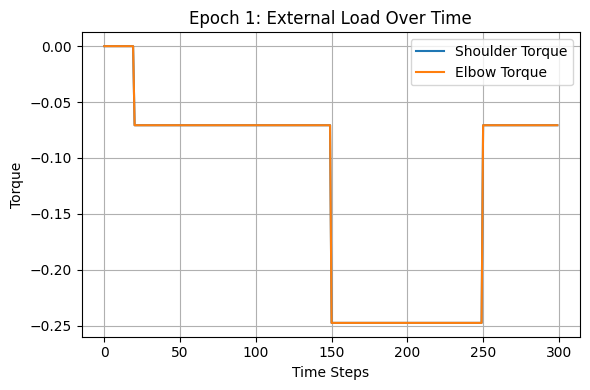

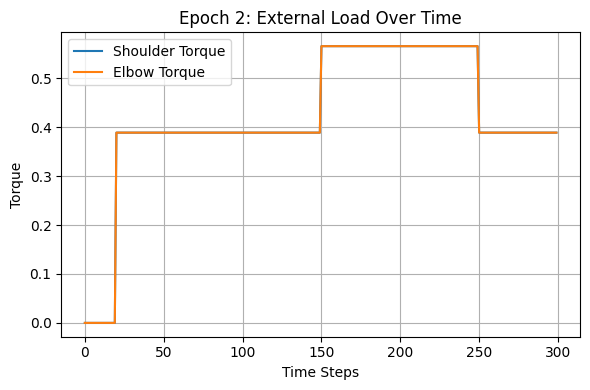

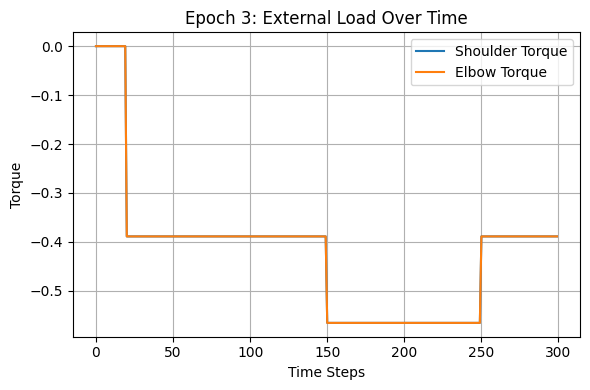

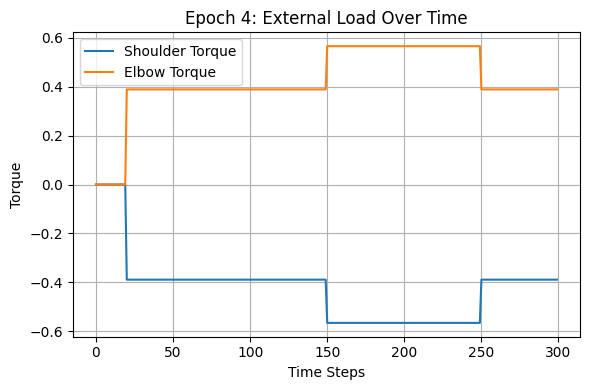

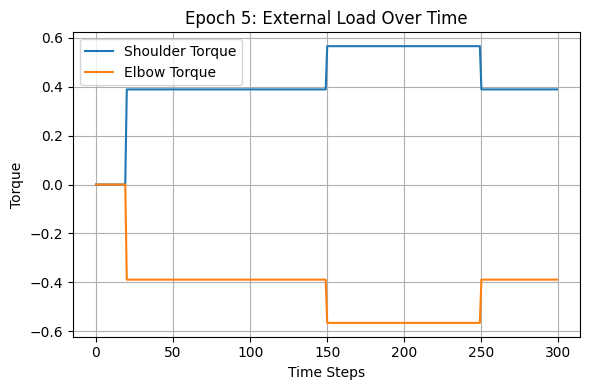

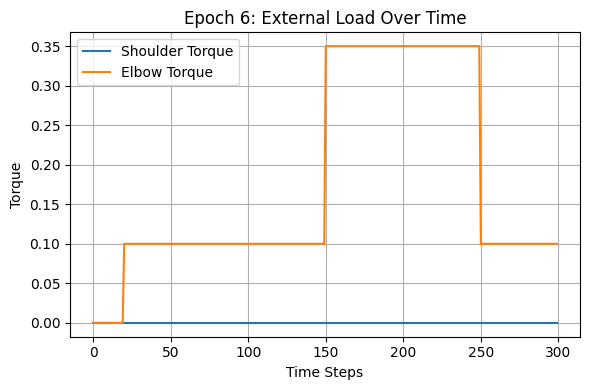

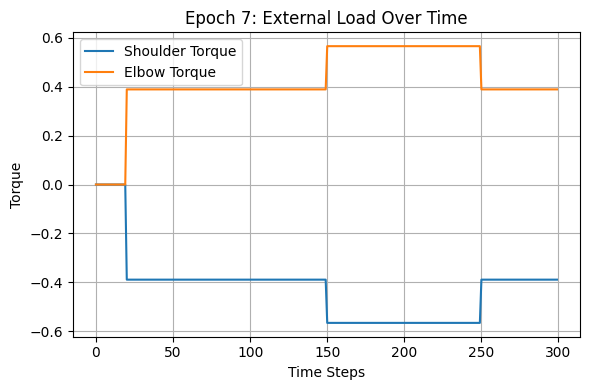

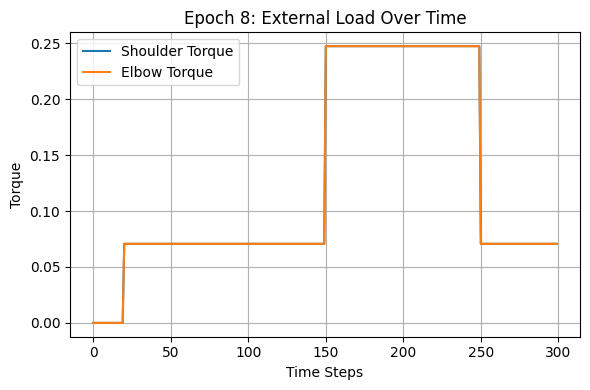

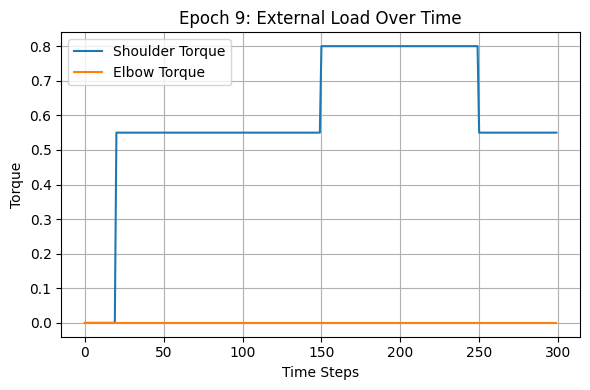

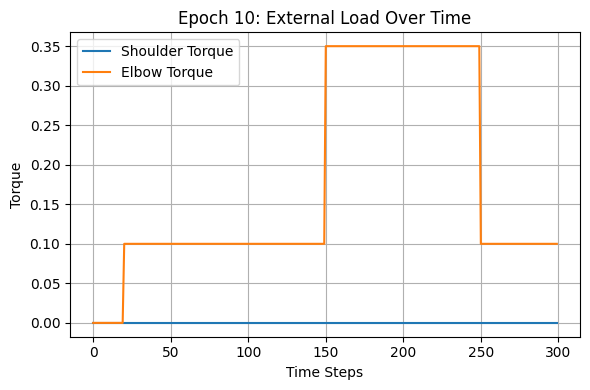

In [9]:
# Plot external load for all epochs
for epoch, external_load in enumerate(epoch_external_loads):
    plt.figure(figsize=(6, 4))
    external_load = np.array(external_load)  # Convert to NumPy array for easier plotting
    plt.plot(external_load[:, 0], label="Shoulder Torque")
    plt.plot(external_load[:, 1], label="Elbow Torque")
    plt.title(f"Epoch {epoch + 1}: External Load Over Time")
    plt.xlabel("Time Steps")
    plt.ylabel("Torque")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

### Plots

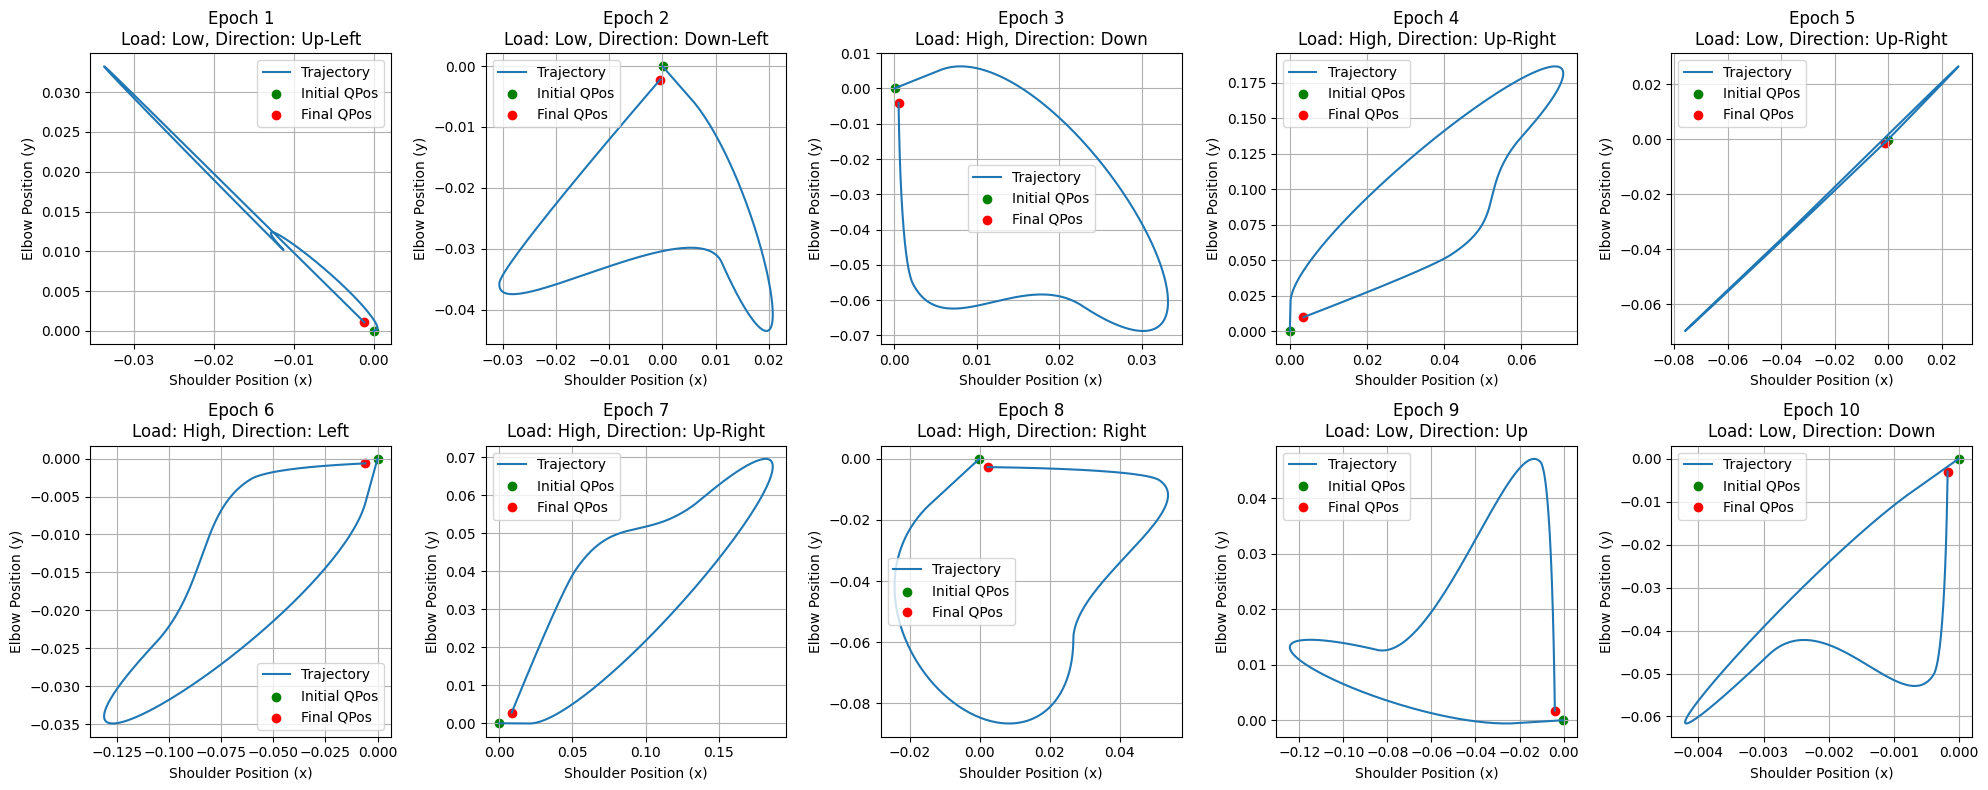

In [ ]:
# Define the number of columns for the subplot grid
num_epochs = len(epoch_metadata)
num_cols = 5  # Number of columns (you can adjust this)
num_rows = math.ceil(num_epochs / num_cols)  # Calculate the number of rows dynamically

# Create the figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))  # Adjust figure size dynamically
axes = axes.flatten()  # Flatten the axes array for easy indexing

# Generate trajectory plots for all epochs
for epoch, metadata in enumerate(epoch_metadata):
    qpos_x, qpos_y = zip(*epoch_qpos_over_time[epoch])  # Use qpos_over_time for the current epoch

    ax = axes[epoch]  # Select the corresponding subplot
    ax.plot(qpos_x, qpos_y, label="Trajectory")
    ax.scatter(qpos_x[0], qpos_y[0], color="green", label="Initial QPos")  # Initial position
    ax.scatter(qpos_x[-1], qpos_y[-1], color="red", label="Final QPos")    # Final position
    ax.set_xlabel("Shoulder Position (x)")
    ax.set_ylabel("Elbow Position (y)")
    ax.set_title(f"Epoch {epoch + 1}\nLoad: {metadata['load']}, Direction: {metadata['direction']}")
    ax.legend()
    ax.grid()

# Hide unused subplots if the number of epochs is less than the total grid size
for i in range(num_epochs, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
def pad_and_compute_mean_std(data, max_length):
    """Pad data with NaN to the maximum length and compute mean and standard deviation."""
    padded_data = np.array([np.pad(epoch, (0, max_length - len(epoch)), constant_values=np.nan) for epoch in data])
    mean = np.nanmean(padded_data, axis=0)
    std = np.nanstd(padded_data, axis=0)
    return mean, std

def plot_mean_and_std(ax, x, mean, std, label, color, alpha=0.1):
    """Plot mean and standard deviation as a shaded region."""
    ax.plot(x, mean, label=label, color=color)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=alpha)

def plot_pose_error(ax, perturbation_results):
    """Plot pose error over time for all perturbations."""
    # Define perturbation direction names
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    num_perturbations = len(perturbation_results)
    colormap = colormaps["tab10"].resampled(num_perturbations)

    for perturbation_idx, perturbation_data in perturbation_results.items():
        pose_errors = perturbation_data["pose_errors"]
        if not pose_errors: 
            continue

        max_length = max(len(epoch) for epoch in pose_errors)
        mean, std = pad_and_compute_mean_std(pose_errors, max_length)
        color = colormap(perturbation_idx / num_perturbations)
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=perturbation_names[perturbation_idx], color=color)
    
    ax.set_title("Pose error over time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Pose error")
    ax.legend(title="Perturbations")
    ax.grid()

def plot_reward(ax, perturbation_results):
    """Plot reward over time for all perturbations."""
    # Define perturbation direction names
    perturbation_names = ["Right", "Left", "Up", "Down", "Up-Right", "Up-Left", "Down-Left", "Down-Right"]
    num_perturbations = len(perturbation_results)
    colormap = colormaps["tab10"].resampled(num_perturbations)

    for perturbation_idx, perturbation_data in perturbation_results.items():
        rewards = perturbation_data["rewards"]
        if not rewards:
            continue

        max_length = max(len(epoch) for epoch in rewards)
        mean, std = pad_and_compute_mean_std(rewards, max_length)
        color = colormap(perturbation_idx / num_perturbations)
        plot_mean_and_std(ax, range(len(mean)), mean, std, label=perturbation_names[perturbation_idx], color=color)
    
    ax.set_title("Reward over time")
    ax.set_xlabel("Time steps")
    ax.set_ylabel("Reward")
    ax.legend(title="Perturbations")
    ax.grid()

def plot_costs(ax, target_results):
    """Plot costs over epochs without aggregating across perturbation directions."""
    cost_keys = ["neural", "force", "J_b", "J_p", "total"]

    # Initialize arrays to store costs for all epochs
    costs = {key: [] for key in cost_keys}
    costs["total"] = []

    # Collect costs for all epochs
    for target_idx, target_data in target_results.items():
        for key in cost_keys:
            # Detach tensors before appending
            costs[key].extend(
                [value.detach().item() if isinstance(value, torch.Tensor) else value for value in target_data["costs"][key]]
            )

    # Recompute total cost as the sum of the individual components
    costs["total"] = np.array(costs["neural"]) + np.array(costs["force"]) + np.array(costs["J_b"]) + np.array(costs["J_p"])
    
    # Convert costs to NumPy arrays
    costs = {key: np.array(values) for key, values in costs.items()}

    # Plot each cost component
    ax.plot(range(1, len(costs["neural"]) + 1), costs["neural"], label="Neural component", color="orange")
    ax.plot(range(1, len(costs["force"]) + 1), costs["force"], label="Force component", linestyle="--", color="cyan")
    ax.plot(range(1, len(costs["J_b"]) + 1), costs["J_b"], label="Kinematic (Jb)", color="blue")
    ax.plot(range(1, len(costs["J_p"]) + 1), costs["J_p"], label="Kinematic (Jp)", color="green")
    ax.plot(range(1, len(costs["total"]) + 1), costs["total"], label="Total cost", color="red")
    ax.set_title("Cost components over epochs")
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Cost")
    ax.legend()
    ax.grid()

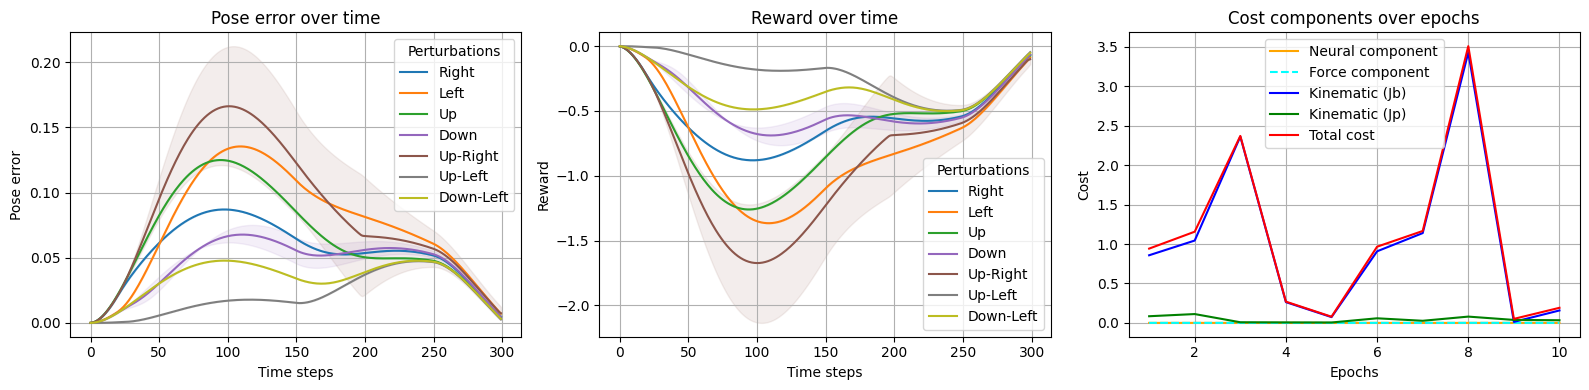

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # Create one row with three plots

plot_pose_error(axes[0], target_results)
plot_reward(axes[1], target_results)
plot_costs(axes[2], target_results)
plt.tight_layout()
plt.show()